# Notebook 04 — Segmentazione clienti

## Obiettivo

Dopo aver esplorato il dataset (Notebook 01), pulito i dati e creato feature derivate (Notebook 02), e condotto un'EDA approfondita per identificare i pattern di spesa e risposta alle campagne (Notebook 03), siamo ora pronti per il passaggio chiave di tutto il progetto: **raggruppare i clienti in segmenti omogenei** che poi useremo, nel Notebook 05, per analizzare l'efficacia delle campagne e formulare raccomandazioni di allocazione del budget.

L'EDA ha mostrato chiaramente che i clienti non sono un blocco uniforme: il top 20% genera il 60-65% del fatturato, la presenza di figli dimezza la spesa, e il reddito correla fortemente con la spesa totale. Trattarli come un unico gruppo significherebbe perdere tutte queste sfumature nelle raccomandazioni finali. La segmentazione è il ponte tra *"abbiamo capito come si comportano i clienti"* e *"sappiamo a chi rivolgere quale campagna"*.

## Approccio metodologico: segmentazione ibrida

Useremo e confronteremo **due approcci diversi**:

1. **RFM (Recency, Frequency, Monetary)** — il metodo classico del retail marketing, basato su tre semplici domande: *quando ha comprato l'ultima volta? quanto spesso compra? quanto spende?* È trasparente, interpretabile, e ampiamente riconosciuto nel settore.

2. **K-Means clustering** — un algoritmo di machine learning che raggruppa i clienti in base alla loro somiglianza su più dimensioni contemporaneamente. Ci permette di includere variabili che l'RFM non considera (come il reddito, la presenza di figli, la responsività alle campagne).

Alla fine confronteremo i risultati dei due metodi tramite una tabella incrociata, per capire dove concordano, dove divergono, e quali insight ciascuno aggiunge.

## Output del notebook

Il deliverable finale sarà un dataset arricchito con **due nuove colonne**: `RFM_Segment` e `KMeans_Cluster`, che useremo nel Notebook 05 per l'analisi delle campagne.

In [1]:
# Setup: import librerie e caricamento dataset pulito

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*libiomp.*')

# Librerie per il clustering
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configurazioni estetiche coerenti con i notebook precedenti
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Riproducibilità: fissiamo il seed per avere risultati identici a ogni esecuzione
RANDOM_STATE = 42

# Caricamento del dataset pulito prodotto dal Notebook 02
DATA_PATH = '../data/marketing_campaign_clean.csv'
df = pd.read_csv(DATA_PATH)
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

print(f"Dataset caricato: {df.shape[0]} righe × {df.shape[1]} colonne")
df.head()

Dataset caricato: 2236 righe × 34 colonne


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Complain,Response,Age,MntTotal,TotalPurchases,TotalCampaignsAccepted,Customer_Tenure_Days,Family_Size,Has_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,1,57,1617,25,1,848,1,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,60,27,6,0,298,3,1
2,4141,1965,Graduation,In_Couple,71613.0,0,0,2013-08-21,26,426,...,0,0,0,49,776,21,0,497,2,0
3,6182,1984,Graduation,In_Couple,26646.0,1,0,2014-02-10,26,11,...,0,0,0,30,53,8,0,324,3,1
4,5324,1981,PhD,In_Couple,58293.0,1,0,2014-01-19,94,173,...,0,0,0,33,422,19,0,346,3,1


## Verifica rapida del dataset

Prima di iniziare la segmentazione, una verifica rapida che il dataset contenga tutte le feature necessarie (create nel Notebook 02) e che non ci siano sorprese.

In [2]:
# Verifichiamo che tutte le variabili che useremo siano presenti e senza valori mancanti
variabili_necessarie = [
    'Income', 'MntTotal', 'Has_Children', 'Recency', 
    'TotalCampaignsAccepted', 'TotalPurchases', 'Dt_Customer'
]

print("Variabili richieste — presenza e missing values:")
for col in variabili_necessarie:
    presente = col in df.columns
    missing = df[col].isnull().sum() if presente else "N/A"
    print(f"  {col:30s} → presente: {presente}, missing: {missing}")

Variabili richieste — presenza e missing values:
  Income                         → presente: True, missing: 0
  MntTotal                       → presente: True, missing: 0
  Has_Children                   → presente: True, missing: 0
  Recency                        → presente: True, missing: 0
  TotalCampaignsAccepted         → presente: True, missing: 0
  TotalPurchases                 → presente: True, missing: 0
  Dt_Customer                    → presente: True, missing: 0


## Sezione 1 — Segmentazione RFM

### Cos'è l'RFM e perché partiamo da qui

L'**RFM** è il metodo di segmentazione più diffuso e longevo del marketing retail, usato sin dagli anni '90 nella gestione dei programmi fedeltà e delle campagne di direct marketing. Il suo nome è un acronimo delle tre dimensioni che usa per descrivere ogni cliente:

- **R — Recency**: *da quanto tempo il cliente non compra?* Un cliente che ha comprato ieri è più "caldo" di uno che non compra da sei mesi.
- **F — Frequency**: *quanto spesso compra?* Un cliente che fa 20 acquisti è più coinvolto di uno che ne ha fatti 2.
- **M — Monetary**: *quanto spende complessivamente?* Un cliente che ha speso 2.000€ ha un valore economico diverso da uno che ha speso 50€.

La forza dell'RFM sta nella sua **semplicità interpretativa**: bastano tre numeri per classificare ogni cliente, e ogni numero risponde a una domanda di business comprensibile da chiunque, anche a chi non conosce la data science. È per questo che è ancora lo standard de facto nei reparti marketing.

### Come funziona operativamente

Il procedimento classico è in tre passi:

1. **Calcolare i tre indicatori** R, F, M per ogni cliente (nel nostro caso li abbiamo praticamente già: `Recency` è già una colonna, `Frequency` la deriviamo da `TotalPurchases`, `Monetary` da `MntTotal`).
2. **Assegnare uno score da 1 a 4 per ogni dimensione**, basato sui quartili. Chi ha Recency bassa (comprato di recente) prende 4; chi ha Frequency e Monetary alte prende 4. In pratica stiamo dicendo: *"in quale quarto della distribuzione cade questo cliente?"*.
3. **Combinare gli score** per assegnare ogni cliente a un **segmento nominato**. Useremo 4 segmenti classici:
   - **Champions** — i migliori su tutti i fronti: comprano di recente, spesso e tanto
   - **Loyal** — clienti solidi, spesso buoni spenditori ma non necessarmente recentissimi
   - **At Risk** — clienti storicamente buoni ma che non comprano da un po': vanno riattivati
   - **Lost** — clienti in gran parte persi: bassa recency, bassa frequency, bassa monetary

### Limiti dell'RFM (che giustificano il K-Means nella Sezione 2)

L'RFM è potente ma **guarda solo al comportamento d'acquisto**. Non sa nulla del reddito del cliente, se ha figli, se ha accettato campagne precedenti. Due clienti con RFM identico ma profili molto diversi (es. uno ricco senza figli e uno con reddito medio e famiglia numerosa) finiscono nello stesso segmento. È per questo che lo affiancheremo al K-Means, che sulle dimensioni "oltre il comportamento d'acquisto" ha molto di più da dire.

In [3]:
# SEZIONE 1.1 — Calcolo delle metriche RFM


# Creiamo un dataframe di lavoro dedicato all'RFM, per tenere pulito il df originale.
# Contiene solo ID cliente e le tre metriche: Recency, Frequency, Monetary.
rfm = df[['ID', 'Recency', 'TotalPurchases', 'MntTotal']].copy()

# Rinominiamo le colonne per usare i nomi canonici RFM
rfm = rfm.rename(columns={
    'TotalPurchases': 'Frequency',
    'MntTotal': 'Monetary'
})

print("Dataframe RFM — struttura e statistiche:")
print(rfm.describe().round(2))
rfm.head()

Dataframe RFM — struttura e statistiche:
             ID  Recency  Frequency  Monetary
count   2236.00  2236.00    2236.00   2236.00
mean    5589.01    49.12      14.87    605.99
std     3244.83    28.96       7.68    601.87
min        0.00     0.00       0.00      5.00
25%     2828.25    24.00       8.00     69.00
50%     5454.50    49.00      15.00    396.50
75%     8421.75    74.00      21.00   1045.50
max    11191.00    99.00      44.00   2525.00


,ID,Recency,Frequency,Monetary
0,5524,58,25,1617
1,2174,38,6,27
2,4141,26,21,776
3,6182,26,8,53
4,5324,94,19,422


### Assegnazione degli score R, F, M

Ora trasformiamo i tre valori numerici (che hanno scale diverse: Recency in giorni, Frequency in numero di acquisti, Monetary in euro) in **score da 1 a 4** basati sui quartili della distribuzione. Questo passaggio è cruciale perché ci permette di mettere sullo stesso piano le tre dimensioni.

**Attenzione a un dettaglio importante sulla Recency**: per Frequency e Monetary *"più alto = meglio"* (più compri, meglio è). Per Recency invece *"più basso = meglio"* (meno giorni da ultimo acquisto = cliente più caldo). Quindi invertiamo l'ordine degli score per Recency: chi ha pochi giorni prende 4, chi ne ha tanti prende 1.

Useremo la funzione `pd.qcut`, che divide una distribuzione in quantili di pari numerosità. Con 4 quantili (quartili), circa il 25% dei clienti finirà in ciascun gruppo per ogni dimensione.

In [4]:
# SEZIONE 1.2 — Score R, F, M via quartili

# Recency: ordine INVERTITO (più giorni = peggio, quindi score più basso).
# labels=[4, 3, 2, 1] assegna 4 al quartile con recency più bassa (clienti "caldi").
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1]).astype(int)

# Frequency: ordine NORMALE (più acquisti = meglio, score più alto).
# Nota: usiamo rank(method='first') come trucco per gestire eventuali ties
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)

# Monetary: ordine NORMALE (più spesa = meglio).
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4]).astype(int)

print("Distribuzione degli score:")
for col in ['R_Score', 'F_Score', 'M_Score']:
    print(f"\n{col}:")
    print(rfm[col].value_counts().sort_index().to_string())

rfm.head(10)

Distribuzione degli score:

R_Score:
R_Score
1    550
2    567
3    554
4    565

F_Score:
F_Score
1    559
2    559
3    559
4    559

M_Score:
M_Score
1    566
2    552
3    559
4    559


,ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,5524,58,25,1617,2,4,4
1,2174,38,6,27,3,1,1
2,4141,26,21,776,3,3,3
3,6182,26,8,53,3,1,1
4,5324,94,19,422,1,3,3
5,7446,16,22,716,4,4,3
6,965,34,21,590,3,3,3
7,6177,32,10,169,3,2,2
8,4855,19,6,46,4,1,1
9,5899,68,2,49,2,1,1


### Dagli score ai segmenti nominati

Abbiamo ora per ogni cliente tre numeri da 1 a 4. Combinati, formano 64 combinazioni possibili (4×4×4). Tenerle tutte sarebbe inutile: un cliente con score `R=3, F=4, M=4` è praticamente indistinguibile, dal punto di vista di business, da uno con `R=4, F=4, M=3`. Dobbiamo **raggruppare le combinazioni in segmenti significativi**.

Adottiamo la semplificazione classica a **4 segmenti**, basata principalmente su due domande:
- *Il cliente compra ancora?* (determinato dalla Recency)
- *Il cliente è un buon cliente?* (determinato da Frequency e Monetary)

| Segmento | Caratteristica | Logica di assegnazione |
|---|---|---|
| **Champions** | Compra di recente, spesso e tanto | R alta E (F alta O M alta) |
| **Loyal** | Buon cliente storico ancora attivo | R media-alta E F/M medio-alte |
| **At Risk** | Era un buon cliente, ora in allontanamento | R bassa MA F/M alte in passato |
| **Lost** | Poco attivo sotto ogni aspetto | Tutto basso |

Per semplificare ulteriormente l'assegnazione, useremo come proxy sintetico la **media di F e M** (che entrambi misurano "quanto vale il cliente") combinata con **R** (che misura "quanto è attivo oggi"). È un approccio pragmatico e robusto, coerente con l'uso operativo dell'RFM nel retail.

Nota metodologica: esistono schemi RFM più sofisticati con 8-11 segmenti (Promising, New Customer, Need Attention, About to Sleep, ecc.). Abbiamo scelto deliberatamente la versione a 4 segmenti perché sarà più facilmente confrontabile con i cluster K-Means della prossima sezione e produce raccomandazioni di business più nette.

In [5]:
# SEZIONE 1.3 — Assegnazione dei 4 segmenti nominati

# Creiamo uno score sintetico "FM" come media di F_Score e M_Score,
# che riassume in un unico numero il "valore storico" del cliente.
rfm['FM_Score'] = (rfm['F_Score'] + rfm['M_Score']) / 2

# Definiamo una funzione che, dati R_Score e FM_Score, restituisce il nome del segmento.
def assegna_segmento(row):
    r = row['R_Score']
    fm = row['FM_Score']
    
    # Champions: attivi di recente E buoni clienti storici
    if r >= 3 and fm >= 3:
        return 'Champions'
    
    # Loyal: buoni clienti storici, recency media
    elif r >= 2 and fm >= 3:
        return 'Loyal'
    
    # At Risk: erano buoni clienti ma non comprano da tempo (recency bassa, FM alto)
    elif r <= 2 and fm >= 3:
        return 'At Risk'
    
    # Lost: tutto il resto (basso su FM, indipendentemente da R)
    else:
        return 'Lost'

# Applichiamo la funzione riga per riga
rfm['RFM_Segment'] = rfm.apply(assegna_segmento, axis=1)

# Verifichiamo la distribuzione dei segmenti
print("Distribuzione dei segmenti RFM:")
distribuzione = rfm['RFM_Segment'].value_counts()
percentuali = rfm['RFM_Segment'].value_counts(normalize=True) * 100

riepilogo = pd.DataFrame({
    'Clienti': distribuzione,
    'Percentuale': percentuali.round(1).astype(str) + '%'
})
print(riepilogo)

Distribuzione dei segmenti RFM:
             Clienti Percentuale
RFM_Segment                     
Lost            1167       52.2%
Champions        527       23.6%
Loyal            293       13.1%
At Risk          249       11.1%


Le **percentuali non sono 25% ciascuno**, nonostante i quartili. Questo perché i *segmenti nascono dalla combinazione di R e FM*, non da un singolo quartile. È normale e atteso: abbiamo più "Lost" e "Champions" che non "Loyal" e "At Risk", perché i clienti tendono a essere coerenti tra R e FM (chi è attivo compra di più, chi è inattivo compra meno).

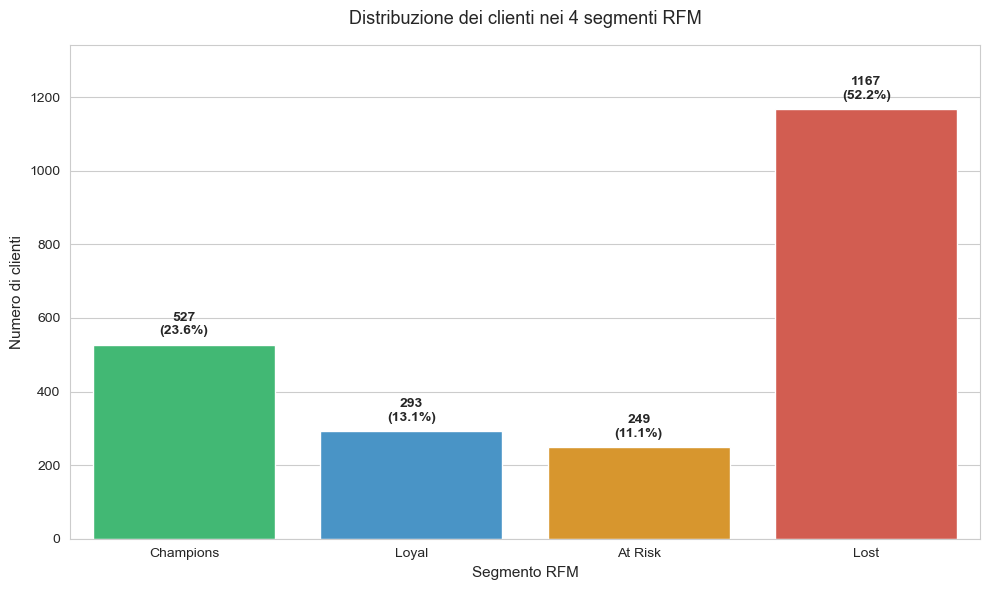

In [6]:
# SEZIONE 1.4 — Visualizzazione della distribuzione

# Palette come DIZIONARIO: in questo modo seaborn mappa i colori ai nomi
# dei segmenti in modo esplicito, indipendentemente dall'ordine dei dati
ordine_segmenti = ['Champions', 'Loyal', 'At Risk', 'Lost']
palette_segmenti = {
    'Champions': '#2ecc71',   # verde — i migliori
    'Loyal':     '#3498db',   # blu — solidi
    'At Risk':   '#f39c12',   # arancio — attenzione
    'Lost':      '#e74c3c'    # rosso — critici
}

fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=rfm, 
    x='RFM_Segment', 
    order=ordine_segmenti,
    hue='RFM_Segment',
    palette=palette_segmenti,  # ora è un dict, quindi la mappatura è esplicita
    legend=False,
    ax=ax
)

# Etichette sopra ogni barra
for i, segmento in enumerate(ordine_segmenti):
    count = (rfm['RFM_Segment'] == segmento).sum()
    pct = count / len(rfm) * 100
    ax.text(i, count + 20, f'{count}\n({pct:.1f}%)', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribuzione dei clienti nei 4 segmenti RFM', fontsize=13, pad=15)
ax.set_xlabel('Segmento RFM', fontsize=11)
ax.set_ylabel('Numero di clienti', fontsize=11)
ax.set_ylim(0, rfm['RFM_Segment'].value_counts().max() * 1.15)

plt.tight_layout()
plt.show()

### Osservazioni sulla distribuzione dei segmenti

La distribuzione dei clienti nei quattro segmenti RFM racconta un quadro nitido del parco clienti, fortemente coerente con gli insight emersi dall'EDA del Notebook 03.

**La base è dominata dal segmento "Lost" (52.2%, 1167 clienti).** Più di un cliente su due è poco attivo sotto tutti i fronti: ha una recency alta e un valore storico (FM) basso. È un dato importante da un punto di vista strategico: suggerisce che l'azienda ha una coda lunga di clienti dormienti o a basso engagement, che probabilmente pesano poco sul fatturato ma costano in termini di gestione della base dati e comunicazioni. Sono il primo target per decisioni di prioritizzazione del budget: riattivarli tutti sarebbe costoso, ignorarli tutti sarebbe uno spreco di potenziale.

**I "Champions" sono il 23.6% (527 clienti),** una proporzione perfettamente allineata con l'insight dell'EDA che il top 20-25% dei clienti genera la maggior parte del fatturato. Sono clienti attivi di recente e con alto valore storico: sono il cuore economico del business e il target naturale di strategie di retention, upselling e programmi di fidelizzazione premium.

**I due segmenti intermedi ("Loyal" 13.1% e "At Risk" 11.1%) sono piccoli ma strategicamente cruciali.** Rappresentano le "zone di transizione" della base clienti: i Loyal sono candidati a diventare Champions con il giusto incentivo, mentre gli At Risk sono clienti ex-buoni che rischiamo di perdere e per cui una campagna di riattivazione mirata può avere un ROI molto alto rispetto al cercare di "risuscitare" i Lost.

**Il rapporto Champions : Lost è circa 1 : 2.2**, il che conferma l'asimmetria tipica dei business retail (pochi clienti generano molto, molti clienti generano poco). Nel prossimo passaggio profileremo ciascun segmento su spesa, reddito e composizione familiare per verificare che queste ipotesi sui "chi sono e quanto valgono" reggano a un'analisi più granulare.

### Profilazione dei segmenti

Fino a questo punto abbiamo assegnato un'etichetta a ogni cliente basandoci esclusivamente sulle tre dimensioni RFM. Ora dobbiamo rispondere alla domanda fondamentale: **chi sono davvero questi clienti?**

La segmentazione, senza profilazione, è un esercizio vuoto: sapere che 527 clienti sono "Champions" non ci serve a nulla se non sappiamo *cosa li rende tali* in termini di variabili osservabili (reddito, età, composizione familiare, abitudini d'acquisto). La profilazione è il ponte tra il risultato algoritmico e le raccomandazioni di business.

Per ciascun segmento calcoleremo:
- **Profilo demografico**: età media, reddito medio, percentuale con figli
- **Profilo comportamentale**: spesa totale media, numero medio di acquisti, recency media
- **Profilo di responsività**: numero medio di campagne accettate, percentuale che ha accettato almeno una campagna

Per farlo dobbiamo prima **unire il dataframe `rfm`** (che contiene i segmenti) **con il dataframe originale `df`** (che contiene tutte le variabili demografiche e comportamentali). Il join avviene sull'`ID` cliente.

In [7]:
# SEZIONE 1.5 — Profilazione dei segmenti

# Uniamo le etichette RFM al dataframe principale tramite l'ID cliente.
# Usiamo un merge left-join: a ogni riga di df aggiungiamo la colonna RFM_Segment.
df_profiled = df.merge(
    rfm[['ID', 'RFM_Segment', 'R_Score', 'F_Score', 'M_Score']],
    on='ID',
    how='left'
)

# Verifica rapida: la dimensione deve restare 2236, nessun cliente perso nel merge
print(f"Righe prima del merge: {len(df)}")
print(f"Righe dopo il merge:   {len(df_profiled)}")
print(f"Missing in RFM_Segment: {df_profiled['RFM_Segment'].isnull().sum()}")
df_profiled[['ID', 'Income', 'MntTotal', 'RFM_Segment']].head()

Righe prima del merge: 2236
Righe dopo il merge:   2236
Missing in RFM_Segment: 0


,ID,Income,MntTotal,RFM_Segment
0,5524,58138.0,1617,Loyal
1,2174,46344.0,27,Lost
2,4141,71613.0,776,Champions
3,6182,26646.0,53,Lost
4,5324,58293.0,422,At Risk


In [8]:
# SEZIONE 1.6 — Tabella riepilogativa di profilazione

# Per ogni segmento calcoliamo le metriche aggregate.
# Usiamo groupby + agg, specificando per ogni colonna la funzione di aggregazione.
profilo = df_profiled.groupby('RFM_Segment').agg(
    n_clienti=('ID', 'count'),
    eta_media=('Age', 'mean'),
    reddito_medio=('Income', 'mean'),
    spesa_media=('MntTotal', 'mean'),
    acquisti_medi=('TotalPurchases', 'mean'),
    recency_media=('Recency', 'mean'),
    pct_con_figli=('Has_Children', 'mean'),          # media di 0/1 = percentuale
    campagne_accettate=('TotalCampaignsAccepted', 'mean'),
    pct_responder=('TotalCampaignsAccepted', lambda x: (x > 0).mean())  # % che ha accettato ≥1 campagna
).round(2)

# Riordiniamo le righe nell'ordine narrativo (Champions → Lost) invece che alfabetico
ordine_segmenti = ['Champions', 'Loyal', 'At Risk', 'Lost']
profilo = profilo.reindex(ordine_segmenti)

# Convertiamo le percentuali in formato leggibile
profilo['pct_con_figli'] = (profilo['pct_con_figli'] * 100).round(1).astype(str) + '%'
profilo['pct_responder'] = (profilo['pct_responder'] * 100).round(1).astype(str) + '%'

print("Profilo medio dei segmenti RFM:")
print("=" * 80)
profilo

Profilo medio dei segmenti RFM:


,n_clienti,eta_media,reddito_medio,spesa_media,acquisti_medi,recency_media,pct_con_figli,campagne_accettate,pct_responder
RFM_Segment,,,,,,,,,
Champions,527,46.50,68189.04,1105.57,21.80,23.75,55.0%,0.82,45.0%
Loyal,293,48.04,66742.33,1093.94,21.35,62.16,58.0%,0.66,37.0%
At Risk,249,46.89,68699.19,1155.98,21.77,87.50,55.0%,0.66,37.0%
Lost,1167,43.35,37342.36,140.52,8.65,49.11,86.0%,0.18,15.0%


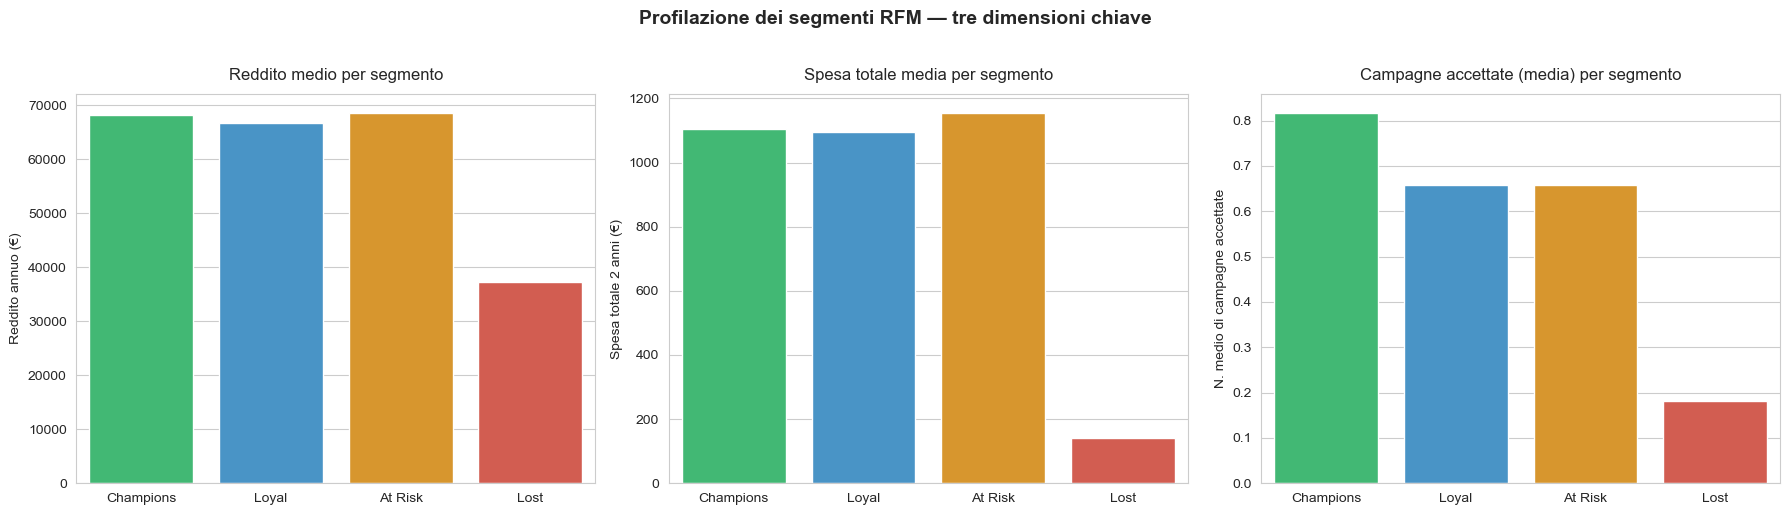

In [9]:
# SEZIONE 1.7 — Visualizzazione dei profili dei segmenti

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

palette_segmenti = {
    'Champions': '#2ecc71', 'Loyal': '#3498db', 
    'At Risk': '#f39c12',   'Lost': '#e74c3c'
}
ordine_segmenti = ['Champions', 'Loyal', 'At Risk', 'Lost']

# --- Grafico 1: Reddito medio per segmento ---
sns.barplot(
    data=df_profiled, x='RFM_Segment', y='Income',
    order=ordine_segmenti, hue='RFM_Segment', palette=palette_segmenti,
    legend=False, ax=axes[0], errorbar=None
)
axes[0].set_title('Reddito medio per segmento', fontsize=12, pad=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('Reddito annuo (€)', fontsize=10)

# --- Grafico 2: Spesa totale media per segmento ---
sns.barplot(
    data=df_profiled, x='RFM_Segment', y='MntTotal',
    order=ordine_segmenti, hue='RFM_Segment', palette=palette_segmenti,
    legend=False, ax=axes[1], errorbar=None
)
axes[1].set_title('Spesa totale media per segmento', fontsize=12, pad=10)
axes[1].set_xlabel('')
axes[1].set_ylabel('Spesa totale 2 anni (€)', fontsize=10)

# --- Grafico 3: Campagne accettate medie per segmento ---
sns.barplot(
    data=df_profiled, x='RFM_Segment', y='TotalCampaignsAccepted',
    order=ordine_segmenti, hue='RFM_Segment', palette=palette_segmenti,
    legend=False, ax=axes[2], errorbar=None
)
axes[2].set_title('Campagne accettate (media) per segmento', fontsize=12, pad=10)
axes[2].set_xlabel('')
axes[2].set_ylabel('N. medio di campagne accettate', fontsize=10)

plt.suptitle('Profilazione dei segmenti RFM — tre dimensioni chiave', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Osservazioni sulla profilazione

La profilazione dei quattro segmenti RFM restituisce un quadro **chiaro ma parzialmente sorprendente**, che vale la pena commentare con attenzione perché illustra sia la forza sia i limiti strutturali del metodo RFM.

**1. La grande separazione: "Lost" vs tutti gli altri.** Il segmento Lost (1167 clienti, 52%) non è semplicemente "meno attivo" degli altri: è un segmento **strutturalmente diverso**. Reddito medio di 37k (contro 67-69k degli altri tre segmenti), spesa totale di 140€ (contro ~1100€), 86% con figli (contro 55-58%), e solo il 15% ha accettato almeno una campagna (contro 37-45%). Questo segmento concentra le famiglie con reddito medio-basso, bassa capacità di spesa e scarsa responsività al marketing: in altre parole, un profilo economicamente e comportamentalmente omogeneo, coerente con l'insight dell'EDA che identificava `Has_Children` come potente discriminante della spesa totale.

**2. Il "falso gradiente" tra Champions, Loyal e At Risk.** Ci saremmo aspettati, a rigore, una scala decrescente di valore economico Champions → Loyal → At Risk. La realtà è diversa: i tre segmenti hanno **redditi, spese totali e acquisti medi praticamente identici** (67-69k di reddito, ~1100€ di spesa, ~21-22 acquisti). L'unica dimensione che li separa davvero è la **Recency**: Champions 24 giorni, Loyal 62, At Risk 87. In pratica, l'RFM ci sta dicendo che questi tre gruppi sono lo stesso tipo di cliente premium, osservato in tre momenti diversi del ciclo di engagement. È una limitazione nota del framework RFM classico, che lavora solo su variabili comportamentali e non "vede" le differenze demografiche tra clienti con comportamenti d'acquisto simili.

**3. La responsività alle campagne segue solo in parte l'RFM.** I Champions sono effettivamente i migliori responder (45% ha accettato almeno una campagna, con media 0.82 campagne accettate), ma Loyal e At Risk sono praticamente allineati tra loro (37%, media 0.66). Il dato più eloquente è il divario con i Lost (15%, media 0.18): l'RFM separa efficacemente i "ricettivi al marketing" dai "non ricettivi", ma non distingue bene all'interno dei ricettivi.

**4. Il profilo "At Risk" merita una nota.** Con la più alta spesa media tra tutti i segmenti (1156€) e una recency di 87 giorni, il segmento At Risk è il più interessante da un punto di vista di ROI delle campagne di riattivazione: sono clienti che hanno storicamente speso molto e che ora stanno scivolando via. Una campagna di win-back mirata su questo segmento (249 clienti) avrebbe costi contenuti e potenziale di recupero economico elevato.

**Implicazioni strategiche preliminari (da raffinare nel Notebook 05):**
- **Champions (527)**: presidio e retention, programmi loyalty premium
- **Loyal (293)**: upselling verso campagne premium per spingerli verso "Champions"
- **At Risk (249)**: campagne di riattivazione mirate — miglior rapporto costi/beneficio atteso
- **Lost (1167)**: valutare attentamente prima di investire, sono clienti strutturalmente diversi e un recupero di massa avrebbe costi alti con ritorno incerto

**Verso la Sezione 2.** Il fatto che Champions, Loyal e At Risk condividano lo stesso profilo economico-demografico è un limite dell'RFM, non del nostro dataset. I clienti "buoni" di questa azienda probabilmente **si articolano in sotto-segmenti diversi** (ad esempio: premium senza figli, famiglie benestanti, heavy-responders alle campagne), ma per vederli servono variabili che l'RFM non considera (`Income`, `Has_Children`, `TotalCampaignsAccepted`). È esattamente il problema per cui useremo il K-Means.

## Sezione 2 — Segmentazione K-Means

### Cos'è il K-Means

Il **K-Means** è l'algoritmo di clustering più usato nella data science, introdotto negli anni '60 e ancora oggi lo standard per segmentazioni esplorative. Il suo compito è semplice da descrivere: dato un insieme di punti in uno spazio multidimensionale, **li raggruppa in K gruppi** (con K scelto da noi) in modo che i punti dello stesso gruppo siano il più possibile vicini tra loro, e lontani dai punti degli altri gruppi.

Nel nostro caso ogni "punto" è un cliente, e le "dimensioni" sono le cinque variabili che abbiamo scelto: `Income`, `MntTotal`, `Has_Children`, `Recency`, `TotalCampaignsAccepted`. Ogni cliente è un punto in uno spazio a 5 dimensioni (che ovviamente non possiamo visualizzare direttamente, ma l'algoritmo lavora lo stesso), e il K-Means trova i gruppi naturali.

### Come funziona, in concreto

L'algoritmo lavora in modo iterativo, ripetendo due passi finché non si stabilizza:

1. **Inizializzazione**: vengono scelti K punti casuali nello spazio (i "centroidi" iniziali, uno per cluster).
2. **Assegnazione**: ogni cliente viene assegnato al cluster il cui centroide è più vicino (in distanza euclidea).
3. **Aggiornamento**: ogni centroide viene spostato nel "baricentro" (media) dei clienti che gli sono stati assegnati.
4. **Ripetizione**: si torna al passo 2. L'algoritmo si ferma quando i centroidi smettono di muoversi significativamente tra un'iterazione e l'altra.

È un'idea sorprendentemente semplice che funziona molto bene nella pratica — almeno quando le variabili sono continue, scalate correttamente e non troppo correlate tra loro.

### Le tre sfide pratiche del K-Means

L'algoritmo, per quanto potente, ha tre "trappole" di cui dobbiamo essere consapevoli prima di usarlo:

**1. La sensibilità alla scala delle variabili.**
Il K-Means misura distanze euclidee. Se una variabile ha valori enormi (come `Income`, che arriva a 162.000) e un'altra ha valori piccoli (come `Has_Children`, che è 0 o 1), la prima domina completamente il calcolo delle distanze e il clustering si baserà praticamente solo su di essa. **Soluzione**: scalare tutte le variabili prima del clustering. Useremo `RobustScaler`, come discusso in apertura di notebook.

**2. La scelta di K non è data dall'algoritmo.**
Il K-Means richiede che *tu* gli dica quanti cluster vuoi. Scegliere male K (troppo pochi o troppi) produce una segmentazione inutile. **Soluzione**: useremo due strumenti combinati per fare una scelta informata — il **metodo del gomito (Elbow Method)** e il **silhouette score**. Li spieghiamo nel dettaglio quando arriviamo al passaggio.

**3. La dipendenza dall'inizializzazione casuale.**
Poiché i centroidi iniziali sono casuali, due esecuzioni dello stesso K-Means possono produrre cluster leggermente diversi. **Soluzione**: due accorgimenti che scikit-learn applica di default — eseguire l'algoritmo più volte (parametro `n_init=10`) tenendo il miglior risultato, e fissare il `random_state` per avere risultati riproducibili.

### Il valore aggiunto rispetto all'RFM

Dove l'RFM guarda solo al comportamento d'acquisto (recency, frequency, monetary), il K-Means può lavorare su dimensioni che l'RFM ignora: il reddito del cliente, la composizione familiare, la responsività storica alle campagne. È quindi un potenziale "microscopio" per trovare struttura all'interno dei segmenti che l'RFM ha mostrato essere troppo omogenei tra loro (Champions, Loyal e At Risk con profili identici).

La domanda che vogliamo farci nella prossima sezione è quindi: **i "clienti buoni" dell'azienda sono davvero un blocco unico, o si suddividono in sotto-gruppi con strategie di business diverse?**

-------------------------------------------------------------------------------------------------------------------------------------------------------

### Preparazione dei dati per il K-Means

Tre passaggi preparatori:

1. **Selezionare le 5 variabili** scelte in apertura di notebook: `Income`, `MntTotal`, `Has_Children`, `Recency`, `TotalCampaignsAccepted`.
2. **Verificare l'assenza di missing values** (dovrebbero essere zero dopo il cleaning del Notebook 02, ma controlliamo sempre).
3. **Applicare lo `RobustScaler`** per mettere le cinque variabili sulla stessa scala, evitando che `Income` e `MntTotal` dominino il calcolo delle distanze.

In [10]:
# SEZIONE 2.1 — Preparazione dei dati per il K-Means

# Variabili scelte per il clustering (decisione presa in apertura di notebook)
variabili_kmeans = ['Income', 'MntTotal', 'Has_Children', 'Recency', 'TotalCampaignsAccepted']

# Estraiamo le variabili dal dataframe originale (non da df_profiled, 
# per evitare confusione con le etichette RFM aggiunte)
X = df[variabili_kmeans].copy()

# Verifica sanity-check: niente missing values
print("Missing values per variabile:")
print(X.isnull().sum())
print(f"\nShape della matrice di input: {X.shape}")
print(f"Righe: {X.shape[0]} clienti × {X.shape[1]} variabili\n")

# Statistiche pre-scaling: notare l'enorme differenza di scala
print("Statistiche PRIMA dello scaling:")
print(X.describe().round(2))

Missing values per variabile:
Income                    0
MntTotal                  0
Has_Children              0
Recency                   0
TotalCampaignsAccepted    0
dtype: int64

Shape della matrice di input: (2236, 5)
Righe: 2236 clienti × 5 variabili

Statistiche PRIMA dello scaling:
          Income  MntTotal  Has_Children  Recency  TotalCampaignsAccepted
count    2236.00   2236.00       2236.00  2236.00                 2236.00
mean    51956.96    605.99          0.72    49.12                    0.45
std     21412.81    601.87          0.45    28.96                    0.89
min      1730.00      5.00          0.00     0.00                    0.00
25%     35502.50     69.00          0.00    24.00                    0.00
50%     51445.50    396.50          1.00    49.00                    0.00
75%     68275.75   1045.50          1.00    74.00                    1.00
max    162397.00   2525.00          1.00    99.00                    5.00


In [11]:
# SEZIONE 2.2 — Applicazione del RobustScaler

# Istanziamo lo scaler. RobustScaler sottrae la mediana e divide per l'IQR,
# rendendolo meno sensibile a valori estremi rispetto allo StandardScaler.
scaler = RobustScaler()

# fit_transform: "impara" i parametri (mediane e IQR) e li applica subito a X
X_scaled = scaler.fit_transform(X)

# fit_transform restituisce un array numpy (non un dataframe).
# Lo riconvertiamo in dataframe per facilità di lettura e uso successivo.
X_scaled = pd.DataFrame(X_scaled, columns=variabili_kmeans, index=X.index)

print("Statistiche DOPO lo scaling (mediane vicine a 0, IQR vicino a 1):")
print(X_scaled.describe().round(2))

Statistiche DOPO lo scaling (mediane vicine a 0, IQR vicino a 1):
        Income  MntTotal  Has_Children  Recency  TotalCampaignsAccepted
count  2236.00   2236.00       2236.00  2236.00                 2236.00
mean      0.02      0.21         -0.28     0.00                    0.45
std       0.65      0.62          0.45     0.58                    0.89
min      -1.52     -0.40         -1.00    -0.98                    0.00
25%      -0.49     -0.34         -1.00    -0.50                    0.00
50%       0.00      0.00          0.00     0.00                    0.00
75%       0.51      0.66          0.00     0.50                    1.00
max       3.39      2.18          0.00     1.00                    5.00


Le **variabili semi-binarie mostrano un pattern particolare**:

**Has_Children**: valori solo -1, 0 (mediana è 1, IQR è 1, quindi dopo scaling: clienti con figli → 0, clienti senza figli → -1). È esattamente come se fosse rimasta 0/1, traslata a -1/0. Va bene così.

**TotalCampaignsAccepted**: 25% e 50% sono entrambi 0 (la maggior parte dei clienti ha accettato zero campagne), quindi l'IQR calcolato da RobustScaler è 1 (tra 0 e 1), e la mediana è 0. Il valore massimo scalato è 5 (un cliente ha accettato tutte e 5 le campagne) — la variabile ha un range più ampio post-scaling rispetto alle altre.

### La scelta di K: Elbow Method e silhouette score

Il K-Means richiede che *noi* decidiamo quanti cluster formare. Scegliere male produce una segmentazione inutile:
- **K troppo piccolo** (es. 2): i cluster raggruppano clienti molto diversi tra loro, perdendo informazione utile.
- **K troppo grande** (es. 10): i cluster diventano microgruppi sovrapposti, difficili da interpretare e senza valore strategico.

Non esiste un "K giusto" assoluto. Esistono però due strumenti complementari che ci aiutano a fare una scelta informata.

**1. Elbow Method (metodo del gomito)**

Per ogni valore di K da 2 a 10, eseguiamo il K-Means e calcoliamo l'**inerzia**, che è la somma delle distanze quadratiche di ogni punto dal centroide del suo cluster. Intuitivamente: quanto sono "compatti" i cluster.

- All'aumentare di K, l'inerzia **diminuisce sempre** (più cluster = ogni cliente è più vicino al proprio centroide).
- Al limite, con K=N (un cluster per ogni cliente), l'inerzia sarebbe zero — ma sarebbe inutile.
- Plottando inerzia vs K otteniamo tipicamente una curva decrescente a "gomito": inizialmente scende ripida, poi si appiattisce.
- Il "gomito" (il punto dove la curva cambia pendenza) è considerato il miglior compromesso tra compattezza dei cluster e parsimonia del modello.

L'Elbow Method è uno strumento visivo: dipende dall'occhio dell'analista. Spesso il gomito non è nettissimo, e questo è il suo limite.

**2. Silhouette score**

Il silhouette score quantifica quanto bene ogni cliente è "piazzato" nel proprio cluster. Per ogni cliente calcola due cose:
- Quanto è **vicino** ai clienti del proprio cluster (coesione)
- Quanto è **lontano** dai clienti del cluster più vicino (separazione)

Il risultato è un numero tra -1 e +1 per ogni cliente:
- **+1**: cliente perfettamente dentro il proprio cluster e lontano dagli altri (ottimo)
- **0**: cliente ai confini tra due cluster (ambiguo)
- **-1**: cliente probabilmente assegnato al cluster sbagliato (cattivo)

Il silhouette score **medio** del clustering è la media di tutti i clienti. Per ogni K testiamo, calcoliamo il silhouette medio e scegliamo il K con il valore più alto — bilanciato, però, con la lettura dell'Elbow, perché a volte un K leggermente peggiore sul silhouette è preferibile se dà cluster più interpretabili.

**Strategia**: calcoleremo entrambe le metriche per K da 2 a 10, le plotteremo affiancate e faremo la scelta finale ragionando sui due grafici insieme.

In [12]:
# SEZIONE 2.3 — Scelta di K: Elbow Method + Silhouette Score

# Range di K da testare. Partiamo da 2 (K=1 significa "tutti in un cluster", inutile)
# e arriviamo a 10 (oltre, la segmentazione perde interpretabilità di business).
range_k = range(2, 11)

# Liste per raccogliere le due metriche al variare di K
inerzie = []
silhouette_scores = []

print("Calcolo Elbow e Silhouette per K = 2 ... 10")
print("-" * 50)

for k in range_k:
    # Istanziamo e addestriamo il K-Means con k cluster
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,                # esegue 10 volte con init diverse, tiene il migliore
        random_state=RANDOM_STATE # riproducibilità
    )
    etichette = kmeans.fit_predict(X_scaled)
    
    # Inerzia (per l'Elbow): è un attributo del modello addestrato
    inerzie.append(kmeans.inertia_)
    
    # Silhouette score (calcolato a parte, sui dati scalati e le etichette)
    sil_score = silhouette_score(X_scaled, etichette)
    silhouette_scores.append(sil_score)
    
    print(f"K = {k:2d} | Inerzia = {kmeans.inertia_:8.1f} | Silhouette = {sil_score:.3f}")

print("-" * 50)
print("Calcolo completato.")

Calcolo Elbow e Silhouette per K = 2 ... 10
--------------------------------------------------


C:\Users\rober\anaconda3\envs\marketing-analytics\Lib\site-packages\threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


K =  2 | Inerzia =   3106.0 | Silhouette = 0.439
K =  3 | Inerzia =   2257.7 | Silhouette = 0.333
K =  4 | Inerzia =   1905.0 | Silhouette = 0.273
K =  5 | Inerzia =   1676.7 | Silhouette = 0.283
K =  6 | Inerzia =   1476.7 | Silhouette = 0.288
K =  7 | Inerzia =   1324.6 | Silhouette = 0.293
K =  8 | Inerzia =   1227.1 | Silhouette = 0.274
K =  9 | Inerzia =   1143.4 | Silhouette = 0.291
K = 10 | Inerzia =   1081.9 | Silhouette = 0.297
--------------------------------------------------
Calcolo completato.


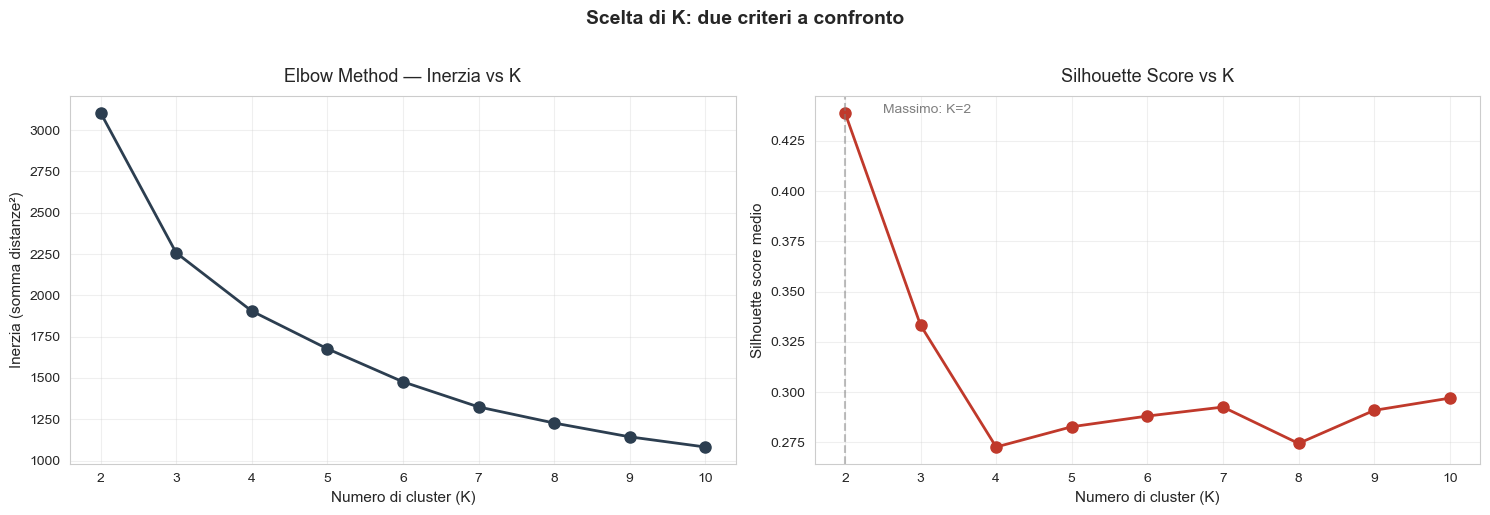


K con silhouette massimo: 2 (silhouette = 0.439)


In [13]:
# SEZIONE 2.4 — Visualizzazione dei due criteri

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Grafico 1: Elbow Method ---
axes[0].plot(range_k, inerzie, marker='o', linestyle='-', 
             color='#2c3e50', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Inerzia vs K', fontsize=13, pad=10)
axes[0].set_xlabel('Numero di cluster (K)', fontsize=11)
axes[0].set_ylabel('Inerzia (somma distanze²)', fontsize=11)
axes[0].set_xticks(list(range_k))
axes[0].grid(True, alpha=0.3)

# --- Grafico 2: Silhouette Score ---
axes[1].plot(range_k, silhouette_scores, marker='o', linestyle='-',
             color='#c0392b', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score vs K', fontsize=13, pad=10)
axes[1].set_xlabel('Numero di cluster (K)', fontsize=11)
axes[1].set_ylabel('Silhouette score medio', fontsize=11)
axes[1].set_xticks(list(range_k))
axes[1].grid(True, alpha=0.3)

# Evidenziamo il K con silhouette massimo
k_best_silhouette = range_k[np.argmax(silhouette_scores)]
axes[1].axvline(x=k_best_silhouette, color='gray', linestyle='--', alpha=0.5)
axes[1].annotate(f'Massimo: K={k_best_silhouette}',
                 xy=(k_best_silhouette, max(silhouette_scores)),
                 xytext=(k_best_silhouette + 0.5, max(silhouette_scores)),
                 fontsize=10, color='gray')

plt.suptitle('Scelta di K: due criteri a confronto', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nK con silhouette massimo: {k_best_silhouette} (silhouette = {max(silhouette_scores):.3f})")

### Lettura dei due criteri e scelta dell'approccio

I due criteri restituiscono letture divergenti, ed è questa divergenza a dover essere analizzata, non "risolta" scegliendo uno dei due.

**Il silhouette score premia K=2** con un valore di 0.439, nettamente superiore a tutti gli altri K (il secondo migliore è K=3 con 0.333). Il silhouette, però, misura la **separazione statistica** dei cluster: premia la soluzione che divide i dati in gruppi più omogenei al loro interno e più distanti tra loro. Quando una dimensione dominante "taglia" il dataset in due parti molto diverse, K=2 vince automaticamente sul silhouette.

**L'Elbow Method** mostra una curva decrescente graduale senza un gomito nettissimo, ma il cambio di pendenza più riconoscibile si colloca tra **K=3 e K=4**: fino a K=4 si guadagna ancora inerzia sensibile a ogni passo, da K=5 in poi i salti diventano marginali.

**Perché K=2 non è la scelta giusta, nonostante il silhouette.** La profilazione dei segmenti RFM ha già mostrato in modo chiaro che il dataset è dominato da una dicotomia forte: *Lost (basso reddito, famiglie con figli, bassa spesa) vs tutti gli altri*. Con quasi certezza, K=2 produrrebbe esattamente questa partizione — che è proprio l'informazione che l'RFM ci ha già dato. Scegliere K=2 renderebbe il K-Means ridondante rispetto all'RFM, vanificando la ragione per cui lo stiamo affiancando.

La domanda che vogliamo porre al K-Means non è *"i clienti si dividono in due gruppi?"* (sì, lo sappiamo già), ma *"i clienti 'buoni' si articolano in sotto-gruppi diversi che l'RFM non ha visto?"*. Per rispondere serve un K ≥ 3.

**Approccio operativo: confronto K=3 vs K=4.**

Testeremo entrambi, fittando il K-Means per ciascuno e profilando i cluster prodotti. La scelta finale sarà basata sull'**interpretabilità di business** dei cluster risultanti, applicando tre criteri:

1. **Ogni cluster deve essere narrativamente distinguibile** dagli altri (profilo economico, demografico o comportamentale chiaramente diverso)
2. **Nessun cluster deve essere troppo piccolo** da risultare inutilizzabile (<5% del dataset)
3. **La segmentazione deve aggiungere informazione** rispetto all'RFM (non ripetere la sola dicotomia Lost / non-Lost)

Questo approccio trasforma la scelta di K da meccanica ("uso quello con silhouette più alto") a ragionata, allineando il criterio statistico con il criterio di business.

In [14]:
# SEZIONE 2.5 — Confronto K=3 vs K=4: fit di entrambi

# Fittiamo entrambi i modelli sui dati scalati
kmeans_3 = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
etichette_k3 = kmeans_3.fit_predict(X_scaled)

kmeans_4 = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE)
etichette_k4 = kmeans_4.fit_predict(X_scaled)

# Aggiungiamo temporaneamente le etichette al dataframe di profilazione
# (che già contiene la colonna RFM_Segment)
df_profiled['Cluster_K3'] = etichette_k3
df_profiled['Cluster_K4'] = etichette_k4

# Verifichiamo la dimensione dei cluster in entrambi i casi
print("Distribuzione dei cluster con K=3:")
print(df_profiled['Cluster_K3'].value_counts().sort_index())
print(f"\nDistribuzione dei cluster con K=4:")
print(df_profiled['Cluster_K4'].value_counts().sort_index())

Distribuzione dei cluster con K=3:
Cluster_K3
0    1303
1     724
2     209
Name: count, dtype: int64

Distribuzione dei cluster con K=4:
Cluster_K4
0    715
1    619
2    203
3    699
Name: count, dtype: int64


In [15]:
# SEZIONE 2.6 — Profilazione dei cluster K=3

profilo_k3 = df_profiled.groupby('Cluster_K3').agg(
    n_clienti=('ID', 'count'),
    reddito_medio=('Income', 'mean'),
    spesa_media=('MntTotal', 'mean'),
    recency_media=('Recency', 'mean'),
    pct_con_figli=('Has_Children', 'mean'),
    campagne_accettate=('TotalCampaignsAccepted', 'mean'),
    pct_responder=('TotalCampaignsAccepted', lambda x: (x > 0).mean()),
    eta_media=('Age', 'mean'),
    acquisti_medi=('TotalPurchases', 'mean')
).round(2)

# Formattiamo le percentuali per leggibilità
profilo_k3['pct_con_figli'] = (profilo_k3['pct_con_figli'] * 100).round(1).astype(str) + '%'
profilo_k3['pct_responder'] = (profilo_k3['pct_responder'] * 100).round(1).astype(str) + '%'

print("=" * 80)
print("PROFILO DEI CLUSTER — K=3")
print("=" * 80)
profilo_k3

PROFILO DEI CLUSTER — K=3


,n_clienti,reddito_medio,spesa_media,recency_media,pct_con_figli,campagne_accettate,pct_responder,eta_media,acquisti_medi
Cluster_K3,,,,,,,,,
0,1303,37724.77,176.01,49.16,89.0%,0.17,15.0%,43.67,10.19
1,724,70954.73,1140.38,50.47,52.0%,0.29,29.0%,47.68,21.53
2,209,74876.33,1435.48,44.13,32.0%,2.73,100.0%,45.09,21.02


In [16]:
# SEZIONE 2.7 — Profilazione dei cluster K=4

profilo_k4 = df_profiled.groupby('Cluster_K4').agg(
    n_clienti=('ID', 'count'),
    reddito_medio=('Income', 'mean'),
    spesa_media=('MntTotal', 'mean'),
    recency_media=('Recency', 'mean'),
    pct_con_figli=('Has_Children', 'mean'),
    campagne_accettate=('TotalCampaignsAccepted', 'mean'),
    pct_responder=('TotalCampaignsAccepted', lambda x: (x > 0).mean()),
    eta_media=('Age', 'mean'),
    acquisti_medi=('TotalPurchases', 'mean')
).round(2)

profilo_k4['pct_con_figli'] = (profilo_k4['pct_con_figli'] * 100).round(1).astype(str) + '%'
profilo_k4['pct_responder'] = (profilo_k4['pct_responder'] * 100).round(1).astype(str) + '%'

print("=" * 80)
print("PROFILO DEI CLUSTER — K=4")
print("=" * 80)
profilo_k4

PROFILO DEI CLUSTER — K=4


,n_clienti,reddito_medio,spesa_media,recency_media,pct_con_figli,campagne_accettate,pct_responder,eta_media,acquisti_medi
Cluster_K4,,,,,,,,,
0,715,39848.18,218.68,73.86,90.0%,0.09,8.0%,44.60,11.15
1,619,72664.69,1210.77,51.38,44.0%,0.30,30.0%,47.56,21.53
2,203,75887.71,1467.81,44.09,30.0%,2.75,100.0%,44.99,21.19
3,699,39055.30,216.31,23.26,88.0%,0.27,23.0%,43.48,10.95


### Scelta finale: K=3

La profilazione dei due candidati restituisce un verdetto netto a favore di **K=3**. Analizziamo il perché applicando i tre criteri enunciati sopra.

**Criterio 1 — Distinguibilità narrativa dei cluster.**
Con K=3 otteniamo tre segmenti che raccontano tre storie di business chiaramente distinte:
- un segmento di famiglie a basso potere d'acquisto (1303 clienti, reddito 37k, 89% con figli, spesa 176€)
- un segmento premium "regolare" (724 clienti, reddito 71k, spesa 1140€, ma bassa responsività al marketing: 29%)
- un segmento premium "super-reattivo alle campagne" (209 clienti, profilo economico simile al precedente ma con il **100% di responder** e 2.73 campagne accettate in media)

Con K=4, invece, il K-Means produce due cluster (0 e 3) che sono **demograficamente ed economicamente identici** — stesso reddito (~39k), stessa spesa (~217€), stessa percentuale con figli (~89%) — e si distinguono unicamente per la **recency** (74gg vs 23gg). I due cluster premium (1 e 2) sono quasi sovrapponibili a quelli di K=3.

**Criterio 2 — Informazione aggiuntiva rispetto all'RFM.**
Qui K=3 vince in modo particolarmente significativo:
- K=3 aggiunge una dimensione discriminante **nuova** rispetto all'RFM: la responsività alle campagne come criterio per dividere i clienti premium. L'RFM aveva mostrato che Champions, Loyal e At Risk avevano profili economici identici; il K-Means ci rivela che al loro interno esiste un sotto-gruppo distinto di "super-responder" che l'RFM non vedeva.
- K=4 spacca il segmento a basso potere d'acquisto sulla base della recency, **che è esattamente l'R-score dell'RFM**. Il K-Means non sta aggiungendo informazione: sta replicando una dimensione che l'RFM già cattura.

**Criterio 3 — Dimensione operativa dei cluster.**
Entrambe le soluzioni hanno il cluster più piccolo attorno al 9% (200-210 clienti), dimensione adeguata per strategie di business mirate. Questo criterio non distingue le due opzioni.

**Sintesi: K=3 emerge come scelta superiore su due dei tre criteri e pari sul terzo**, confermando la validità dell'approccio metodologico di privilegiare l'interpretabilità di business sul silhouette score puro.

**Un insight bonus.** Il terzo cluster di K=3 — 209 clienti con il 100% di responder e 2.73 campagne accettate — è il pezzo di informazione più prezioso di tutta la sezione. Era invisibile all'RFM (dove era distribuito tra Champions, Loyal e in parte At Risk) e rappresenta il target naturale per l'ottimizzazione del budget delle campagne che analizzeremo nel Notebook 05: un piccolo gruppo di clienti con reattività massima, dove un euro investito ha probabilità di ritorno sostanzialmente superiore alla media.

### Nomi parlanti per i cluster

Per facilitare la lettura dei prossimi notebook, assegniamo ai tre cluster nomi descrittivi invece dei numeri arbitrari:

| Cluster ID | Nome | Profilo sintetico |
|---|---|---|
| 0 | **Budget Families** | Reddito medio-basso, famiglie con figli, bassa spesa e bassa responsività |
| 1 | **Affluent Regulars** | Reddito e spesa elevati, responsività moderata alle campagne |
| 2 | **Campaign Enthusiasts** | Reddito e spesa elevati, responsività totale alle campagne (100%) |

Nota: abbiamo scelto "Campaign Enthusiasts" invece di "Campaign Champions" per evitare confusione con il segmento "Champions" dell'RFM, che rappresenta un concetto diverso (recency alta + FM alto, non responsività).

In [17]:
# SEZIONE 2.8 — Fit definitivo con K=3 e assegnazione nomi parlanti

# Fit finale (lo rifacciamo per chiarezza narrativa, pur avendo già l'etichetta da prima)
kmeans_final = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
etichette_finali = kmeans_final.fit_predict(X_scaled)

# Mappatura cluster ID → nome parlante
# ATTENZIONE: la mappatura dipende dai profili osservati nella cella 26.
# Verifica che l'ID 0 sia ancora il "Budget Families", l'1 sia "Affluent Regulars", ecc.
# Se il random_state è fisso, la mappatura è stabile tra esecuzioni.
nomi_cluster = {
    0: 'Budget Families',
    1: 'Affluent Regulars',
    2: 'Campaign Enthusiasts'
}

# Creiamo la colonna definitiva KMeans_Cluster nel dataframe arricchito
df_profiled['KMeans_Cluster'] = pd.Series(etichette_finali).map(nomi_cluster).values

# Rimuoviamo le colonne temporanee di confronto K=3/K=4, non ci servono più
df_profiled = df_profiled.drop(columns=['Cluster_K3', 'Cluster_K4'])

# Verifichiamo la distribuzione finale
print("Distribuzione definitiva dei cluster K-Means:")
print("-" * 50)
distribuzione = df_profiled['KMeans_Cluster'].value_counts()
percentuali = df_profiled['KMeans_Cluster'].value_counts(normalize=True) * 100
riepilogo = pd.DataFrame({
    'Clienti': distribuzione,
    'Percentuale': percentuali.round(1).astype(str) + '%'
})
print(riepilogo)

print(f"\nDataset arricchito: {df_profiled.shape[0]} righe × {df_profiled.shape[1]} colonne")
print(f"Nuove colonne aggiunte rispetto al dataset originale: RFM_Segment, R_Score, F_Score, M_Score, KMeans_Cluster")

Distribuzione definitiva dei cluster K-Means:
--------------------------------------------------
                      Clienti Percentuale
KMeans_Cluster                           
Budget Families          1303       58.3%
Affluent Regulars         724       32.4%
Campaign Enthusiasts      209        9.3%

Dataset arricchito: 2236 righe × 39 colonne
Nuove colonne aggiunte rispetto al dataset originale: RFM_Segment, R_Score, F_Score, M_Score, KMeans_Cluster


### Visualizzazione dei cluster

Per comprendere visivamente la struttura del K-Means, riportiamo i clienti su due piani cartesiani costruiti con le variabili più discriminanti:

1. **Income vs MntTotal** — mostra come i cluster si separano sul "potere d'acquisto realizzato"
2. **MntTotal vs TotalCampaignsAccepted** — mostra il vero valore aggiunto del K-Means: la separazione dei Campaign Enthusiasts

Ogni punto è un cliente, colorato secondo il cluster di appartenenza.

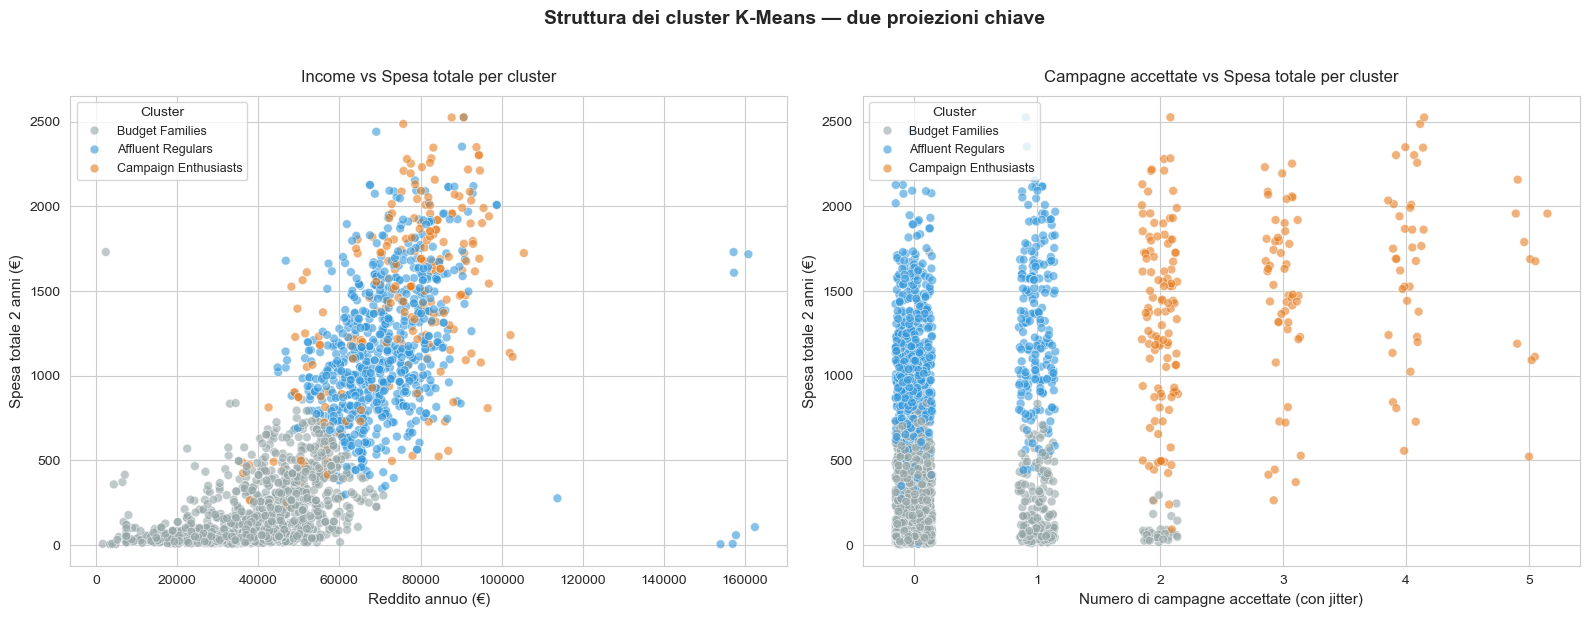

In [18]:
# SEZIONE 2.9 — Visualizzazione dei cluster

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Palette coerente per i cluster K-Means (diversa da quella RFM per distinguere le due segmentazioni)
palette_kmeans = {
    'Budget Families':      '#95a5a6',   # grigio — base clienti ampia ma meno strategica
    'Affluent Regulars':    '#3498db',   # blu — clienti premium "base"
    'Campaign Enthusiasts': '#e67e22'    # arancione acceso — il cluster strategico
}
ordine_cluster = ['Budget Families', 'Affluent Regulars', 'Campaign Enthusiasts']

# --- Grafico 1: Income vs MntTotal ---
sns.scatterplot(
    data=df_profiled,
    x='Income', y='MntTotal',
    hue='KMeans_Cluster', hue_order=ordine_cluster,
    palette=palette_kmeans,
    alpha=0.6, s=40, ax=axes[0]
)
axes[0].set_title('Income vs Spesa totale per cluster', fontsize=12, pad=10)
axes[0].set_xlabel('Reddito annuo (€)', fontsize=11)
axes[0].set_ylabel('Spesa totale 2 anni (€)', fontsize=11)
axes[0].legend(title='Cluster', loc='upper left', fontsize=9)

# --- Grafico 2: MntTotal vs TotalCampaignsAccepted ---
# Aggiungiamo un piccolo jitter sulla x discreta per visibilità
jitter = np.random.uniform(-0.15, 0.15, size=len(df_profiled))
df_plot = df_profiled.copy()
df_plot['Campaigns_jitter'] = df_plot['TotalCampaignsAccepted'] + jitter

sns.scatterplot(
    data=df_plot,
    x='Campaigns_jitter', y='MntTotal',
    hue='KMeans_Cluster', hue_order=ordine_cluster,
    palette=palette_kmeans,
    alpha=0.6, s=40, ax=axes[1]
)
axes[1].set_title('Campagne accettate vs Spesa totale per cluster', fontsize=12, pad=10)
axes[1].set_xlabel('Numero di campagne accettate (con jitter)', fontsize=11)
axes[1].set_ylabel('Spesa totale 2 anni (€)', fontsize=11)
axes[1].set_xticks(range(6))
axes[1].legend(title='Cluster', loc='upper left', fontsize=9)

plt.suptitle('Struttura dei cluster K-Means — due proiezioni chiave',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Osservazioni sui grafici dei cluster

I due scatterplot rivelano in modo molto chiaro la struttura che il K-Means ha trovato nei dati, e forniscono una conferma visiva di tutti gli insight emersi nella profilazione.

**Grafico 1 (Income vs Spesa totale) — la dicotomia di base.**
I **Budget Families** occupano un quadrante nettamente separato (basso reddito, bassa spesa), formando una nuvola compatta che replica geometricamente la dicotomia "Lost vs non-Lost" già emersa dall'RFM. I due cluster premium (**Affluent Regulars** e **Campaign Enthusiasts**) si sovrappongono considerevolmente su questo piano: entrambi occupano la regione alto-reddito/alta-spesa, senza una separazione geometrica netta. Questo conferma quantitativamente ciò che i numeri della profilazione avevano già suggerito — **il reddito e la spesa, presi da soli, non distinguono i due cluster premium**.

**Grafico 2 (Campagne accettate vs Spesa) — il vero discriminante.**
È in questa proiezione che la separazione tra i cluster premium diventa evidente e netta. I Campaign Enthusiasts sono concentrati sulla destra del grafico (2-5 campagne accettate) mentre gli Affluent Regulars si concentrano a sinistra (0-1 campagne). Questo è il **valore aggiunto fondamentale del K-Means rispetto all'RFM**: la responsività alle campagne emerge come dimensione discriminante autonoma che l'RFM non poteva catturare.

**Una sfumatura interessante: la multidimensionalità del clustering.**
Osservando attentamente il grafico 2 su x=1 (una campagna accettata), troviamo rappresentati tutti e tre i cluster. Questo suggerisce che il K-Means **non usa la responsività come criterio isolato**: per essere classificato come Campaign Enthusiast, un cliente deve combinare responsività alle campagne *e* profilo economico elevato. Un cliente con reddito basso che ha accettato una campagna resta un Budget Family; il cluster Enthusiasts emerge come intersezione di più dimensioni, non come proiezione su una sola.

**Implicazioni per il Notebook 05.**
La separazione visiva così netta dei Campaign Enthusiasts sulla dimensione "campagne accettate" ha un'implicazione operativa importante: questi 209 clienti sono quelli per cui possiamo prevedere con ragionevole certezza che **risponderanno positivamente a una campagna futura**. Il calcolo dell'efficacia delle campagne per segmento e le raccomandazioni di allocazione del budget si costruiranno in buona parte attorno a questa evidenza.

### Bilancio della Sezione 2

Il K-Means su 5 variabili scalate ha prodotto una segmentazione in 3 cluster che rispondono alla domanda aperta dalla Sezione 1: **i "clienti buoni" non sono un blocco unico**, ma si dividono in due sotto-segmenti con strategie di marketing potenzialmente molto diverse.

| Cluster | Dimensione | Profilo distintivo | Leva strategica |
|---|---|---|---|
| **Budget Families** | 1303 (58%) | Basso reddito, famiglie con figli, bassa spesa e responsività | Rivedere l'opportunità stessa di includerli nelle campagne |
| **Affluent Regulars** | 724 (32%) | Reddito e spesa elevati, responsività moderata | Potenziale di conversione — capire cosa li renderebbe più reattivi |
| **Campaign Enthusiasts** | 209 (9%) | Reddito e spesa elevati, responsività totale (100%) | Protagonisti del budget campagne — ROI atteso massimo |

Nella **Sezione 3** confronteremo in dettaglio questa segmentazione con quella RFM per capire esattamente dove le due letture concordano e dove divergono, e nel **Notebook 05** useremo entrambe (o quella che si rivelerà più informativa) per analizzare l'efficacia storica delle campagne e formulare raccomandazioni di budget.

## Sezione 3 — Confronto RFM vs K-Means

### L'obiettivo del confronto

Abbiamo prodotto due segmentazioni indipendenti degli stessi 2236 clienti, usando metodi molto diversi tra loro:

- **RFM** ha classificato i clienti sulla base di tre indicatori comportamentali (quando, quanto spesso, quanto spendono) in 4 segmenti: Champions, Loyal, At Risk, Lost
- **K-Means** ha raggruppato i clienti in base alla somiglianza multidimensionale su 5 variabili (reddito, spesa, presenza di figli, recency, campagne accettate) in 3 cluster: Budget Families, Affluent Regulars, Campaign Enthusiasts

La domanda che ci poniamo in questa sezione è: **i due metodi "vedono" gli stessi clienti allo stesso modo?** In particolare:
- Ci sono sovrapposizioni forti (es. tutti i Lost RFM sono anche Budget Families K-Means)?
- Ci sono divergenze sistematiche che rivelano angoli ciechi dell'uno o dell'altro metodo?
- Quale delle due segmentazioni porteremo avanti nel Notebook 05, o le useremo entrambe in modo complementare?

### Metodologia: crosstab + heatmap

Lo strumento più naturale e interpretabile per questo confronto è la **tabella di contingenza** (crosstab): una matrice dove ogni riga è un segmento RFM, ogni colonna è un cluster K-Means, e ogni cella contiene il numero di clienti classificati in entrambi i modi.

Dalla crosstab possiamo derivare tre letture:

1. **Crosstab assoluta**: i numeri grezzi, utili per cogliere le dimensioni dei sottogruppi
2. **Crosstab in percentuale di riga**: "di tutti i Champions RFM, quanti sono Budget Families vs Affluent vs Enthusiasts?" — legge il K-Means dalla prospettiva dell'RFM
3. **Crosstab in percentuale di colonna**: "di tutti gli Affluent Regulars K-Means, quanti sono Champions vs Loyal vs At Risk vs Lost?" — legge l'RFM dalla prospettiva del K-Means

Visualizzeremo ciascuna come **heatmap**, perché il colore restituisce immediatamente i pattern di concentrazione che i soli numeri richiederebbero più tempo per essere colti.

In [19]:
# SEZIONE 3.1 — Costruzione delle crosstab

# Ordine dei segmenti/cluster: narrativo, non alfabetico
ordine_rfm = ['Champions', 'Loyal', 'At Risk', 'Lost']
ordine_kmeans = ['Campaign Enthusiasts', 'Affluent Regulars', 'Budget Families']

# 1. Crosstab assoluta: conteggi grezzi
crosstab_assoluta = pd.crosstab(
    df_profiled['RFM_Segment'],
    df_profiled['KMeans_Cluster']
)
# Riordiniamo righe e colonne nell'ordine narrativo
crosstab_assoluta = crosstab_assoluta.reindex(index=ordine_rfm, columns=ordine_kmeans)

# 2. Crosstab in percentuale di RIGA (come si distribuisce ogni segmento RFM tra i cluster K-Means)
crosstab_pct_riga = pd.crosstab(
    df_profiled['RFM_Segment'],
    df_profiled['KMeans_Cluster'],
    normalize='index'  # 'index' = normalizza per riga
) * 100
crosstab_pct_riga = crosstab_pct_riga.reindex(index=ordine_rfm, columns=ordine_kmeans)

# 3. Crosstab in percentuale di COLONNA (come si distribuisce ogni cluster K-Means tra i segmenti RFM)
crosstab_pct_colonna = pd.crosstab(
    df_profiled['RFM_Segment'],
    df_profiled['KMeans_Cluster'],
    normalize='columns'  # 'columns' = normalizza per colonna
) * 100
crosstab_pct_colonna = crosstab_pct_colonna.reindex(index=ordine_rfm, columns=ordine_kmeans)

# Stampa le tre tabelle affiancate
print("=" * 80)
print("CROSSTAB ASSOLUTA — numero di clienti")
print("=" * 80)
print(crosstab_assoluta)

print("\n" + "=" * 80)
print("CROSSTAB % DI RIGA — distribuzione di ogni segmento RFM nei cluster K-Means")
print("=" * 80)
print(crosstab_pct_riga.round(1))

print("\n" + "=" * 80)
print("CROSSTAB % DI COLONNA — distribuzione di ogni cluster K-Means nei segmenti RFM")
print("=" * 80)
print(crosstab_pct_colonna.round(1))

CROSSTAB ASSOLUTA — numero di clienti
KMeans_Cluster  Campaign Enthusiasts  Affluent Regulars  Budget Families
RFM_Segment                                                             
Champions                        115                326               86
Loyal                             46                186               61
At Risk                           41                168               40
Lost                               7                 44             1116

CROSSTAB % DI RIGA — distribuzione di ogni segmento RFM nei cluster K-Means
KMeans_Cluster  Campaign Enthusiasts  Affluent Regulars  Budget Families
RFM_Segment                                                             
Champions                       21.8               61.9             16.3
Loyal                           15.7               63.5             20.8
At Risk                         16.5               67.5             16.1
Lost                             0.6                3.8             95.6

CROSSTAB

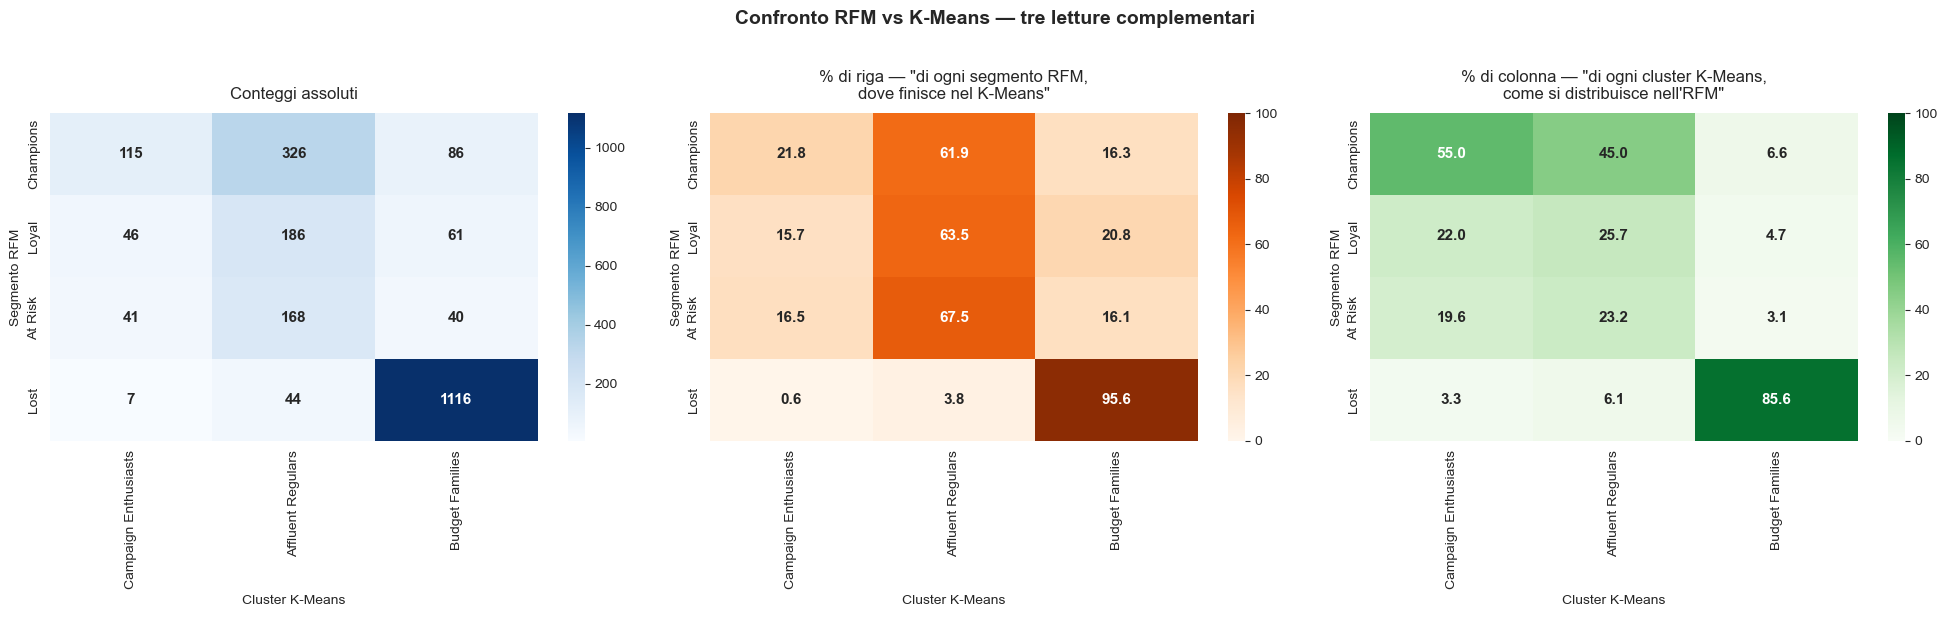

In [20]:
# SEZIONE 3.2 — Heatmap di confronto RFM × K-Means

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Heatmap 1: conteggi assoluti ---
sns.heatmap(
    crosstab_assoluta, annot=True, fmt='d',
    cmap='Blues', cbar=True,
    ax=axes[0], annot_kws={'fontsize': 11, 'fontweight': 'bold'}
)
axes[0].set_title('Conteggi assoluti', fontsize=12, pad=10)
axes[0].set_xlabel('Cluster K-Means', fontsize=10)
axes[0].set_ylabel('Segmento RFM', fontsize=10)

# --- Heatmap 2: percentuali di riga ---
sns.heatmap(
    crosstab_pct_riga, annot=True, fmt='.1f',
    cmap='Oranges', cbar=True,
    ax=axes[1], annot_kws={'fontsize': 11, 'fontweight': 'bold'},
    vmin=0, vmax=100
)
axes[1].set_title('% di riga — "di ogni segmento RFM,\ndove finisce nel K-Means"',
                  fontsize=12, pad=10)
axes[1].set_xlabel('Cluster K-Means', fontsize=10)
axes[1].set_ylabel('Segmento RFM', fontsize=10)

# --- Heatmap 3: percentuali di colonna ---
sns.heatmap(
    crosstab_pct_colonna, annot=True, fmt='.1f',
    cmap='Greens', cbar=True,
    ax=axes[2], annot_kws={'fontsize': 11, 'fontweight': 'bold'},
    vmin=0, vmax=100
)
axes[2].set_title('% di colonna — "di ogni cluster K-Means,\ncome si distribuisce nell\'RFM"',
                  fontsize=12, pad=10)
axes[2].set_xlabel('Cluster K-Means', fontsize=10)
axes[2].set_ylabel('Segmento RFM', fontsize=10)

plt.suptitle('Confronto RFM vs K-Means — tre letture complementari',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Osservazioni sul confronto

Il confronto tra le due segmentazioni rivela quattro pattern distinti, ciascuno con implicazioni metodologiche e operative.

**1. Concordanza quasi totale sulla dicotomia di base: Lost ≈ Budget Families (1116 clienti).**

Il 95.6% dei clienti classificati come "Lost" dall'RFM è anche classificato come "Budget Families" dal K-Means, e viceversa l'85.6% dei Budget Families è anche Lost. Su 2236 clienti, 1116 (il 50% del dataset) sono classificati in modo equivalente dai due metodi. Questo è un risultato metodologicamente importante: due approcci partiti da variabili completamente diverse — comportamentali per l'RFM, multidimensionali per il K-Means — sono arrivati alla stessa conclusione su questo sottogruppo. È una **validazione reciproca** che conferma la realtà di questo segmento di clienti a basso potere d'acquisto e bassa responsività. Non è un artefatto di metodo.

**2. Il vero valore aggiunto del K-Means: la frammentazione dei Champions RFM.**

I 527 Champions RFM si distribuiscono in modo sorprendente nei tre cluster K-Means:
- 326 (61.9%) sono Affluent Regulars — profilo premium "standard"
- 115 (21.8%) sono Campaign Enthusiasts — super-responsivi alle campagne
- **86 (16.3%) sono Budget Families** — profilo socio-economico modesto

Questi 86 clienti "Champions ma Budget Families" rivelano un **limite strutturale dell'RFM classico**: i quartili producono segmenti *relativi* al dataset, non assoluti al potere di spesa reale. Un cliente può essere Champion rispetto alla distribuzione complessiva pur avendo reddito e spesa modesti in termini assoluti. Per decisioni di allocazione budget questa distinzione è cruciale: premiare tutti i Champions con campagne premium include clienti che probabilmente non hanno capacità di conversione, mentre la segmentazione K-Means li separa correttamente.

**3. Loyal, At Risk e Champions sono la stessa popolazione in momenti diversi.**

Confrontando le righe di Champions, Loyal e At Risk nella seconda heatmap (% di riga), la distribuzione tra i cluster K-Means è praticamente identica:

| Segmento RFM | % Campaign Enthusiasts | % Affluent Regulars | % Budget Families |
|---|---|---|---|
| Champions | 21.8% | 61.9% | 16.3% |
| Loyal | 15.7% | 63.5% | 20.8% |
| At Risk | 16.5% | 67.5% | 16.1% |

Questo conferma in modo quantitativo l'ipotesi già emersa dalla profilazione RFM: **i tre segmenti "alti" dell'RFM sono la stessa popolazione di clienti**, osservata in tre momenti diversi del ciclo di engagement (recente / medio / remoto). Il K-Means, che non usa la recency come variabile dominante, li vede come un'unica popolazione internamente differenziata per responsività alle campagne.

**4. Gli "ibridi" strategici: 51 Lost non-Budget e 41 At Risk iper-responsivi.**

Due piccoli sottogruppi emergono dal confronto e meritano attenzione operativa dedicata nel Notebook 05:

- **51 clienti Lost RFM ma non Budget Families K-Means** (44 Affluent Regulars + 7 Campaign Enthusiasts). Sono clienti con profilo socio-economico alto e storia di responsività, ma recency e frequency recenti pessime. L'RFM li "cancella"; il K-Means li conserva come potenziali. Sono candidati naturali per campagne di win-back mirate.
- **41 clienti At Risk RFM e Campaign Enthusiasts K-Means**. Sono il sottogruppo strategicamente più interessante di tutto il dataset: hanno storicamente accettato più campagne ma non comprano da 80+ giorni. Una campagna di riattivazione indirizzata a questo gruppo ha probabilità di successo particolarmente elevate, dato che sappiamo *ex ante* che rispondono positivamente al marketing diretto.

### Implicazioni per il Notebook 05

Il confronto suggerisce una **strategia di utilizzo combinato** delle due segmentazioni nel prossimo notebook:

- **Il K-Means** è lo strumento migliore per decisioni di **allocazione del budget complessivo**: fornisce una lettura socio-economica affidabile e separa correttamente i clienti con capacità di conversione dai dormienti strutturali
- **L'RFM** è lo strumento migliore per decisioni di **timing delle campagne**: cattura le dinamiche di recency che il K-Means usa solo marginalmente, ed è più diretto per identificare chi riattivare e chi fidelizzare

Per questo motivo porteremo **entrambe le segmentazioni** nel dataset arricchito e le useremo in modo complementare: K-Means per il "quanto investire su chi", RFM per il "quando e come attivarlo".

## Sezione 4 — Sintesi finale e preparazione del Notebook 05

### Chiusura della Sezione 3

Il confronto tra RFM e K-Means ha prodotto quattro insight chiave: forte concordanza sulla dicotomia di base (Lost ≈ Budget Families), valore aggiunto del K-Means nella frammentazione dei Champions, conferma che Loyal/At Risk/Champions sono la stessa popolazione in momenti diversi, ed emersione di due sottogruppi "ibridi" strategicamente preziosi.

### Sintesi del Notebook 04

Abbiamo prodotto due segmentazioni complementari, che porteremo entrambe al Notebook 05 per usarle in modo combinato.

In [21]:
# SEZIONE 4.1 — Tabella riepilogativa delle due segmentazioni

riepilogo = pd.DataFrame({
    'Segmentazione': ['RFM', 'RFM', 'RFM', 'RFM', 
                      'K-Means', 'K-Means', 'K-Means'],
    'Segmento/Cluster': ['Champions', 'Loyal', 'At Risk', 'Lost',
                         'Campaign Enthusiasts', 'Affluent Regulars', 'Budget Families'],
    'N clienti': [527, 293, 249, 1167, 209, 724, 1303],
    '%': ['23.6%', '13.1%', '11.1%', '52.2%', '9.3%', '32.4%', '58.3%'],
    'Leva strategica': [
        'Retention premium',
        'Upselling verso Champions',
        'Campagne di riattivazione (alto ROI atteso)',
        'Investimento selettivo',
        'Target prioritario campagne (ROI massimo)',
        'Conversione a maggior responsività',
        'Rivalutare inclusione nelle campagne premium'
    ]
})

print("Riepilogo finale delle due segmentazioni:")
print("=" * 90)
riepilogo

Riepilogo finale delle due segmentazioni:


,Segmentazione,Segmento/Cluster,N clienti,%,Leva strategica
0,RFM,Champions,527,23.6%,Retention premium
1,RFM,Loyal,293,13.1%,Upselling verso Champions
2,RFM,At Risk,249,11.1%,Campagne di riattivazione (alto ROI atteso)
3,RFM,Lost,1167,52.2%,Investimento selettivo
4,K-Means,Campaign Enthusiasts,209,9.3%,Target prioritario campagne (ROI massimo)
5,K-Means,Affluent Regulars,724,32.4%,Conversione a maggior responsività
6,K-Means,Budget Families,1303,58.3%,Rivalutare inclusione nelle campagne premium


### Salvataggio del dataset arricchito

Salviamo il dataset con le due nuove colonne (`RFM_Segment` e `KMeans_Cluster`) in modo che il Notebook 05 possa caricarlo direttamente senza ricalcolare le segmentazioni.

In [22]:
# SEZIONE 4.2 — Salvataggio del dataset arricchito

# Selezioniamo le colonne da salvare: dataset originale + le due etichette di segmentazione
# (tralasciamo R_Score, F_Score, M_Score che sono intermedie e non servono al Notebook 05)
colonne_finali = [c for c in df_profiled.columns 
                  if c not in ['R_Score', 'F_Score', 'M_Score']]
df_output = df_profiled[colonne_finali]

# Salvataggio
output_path = '../data/marketing_campaign_segmented.csv'
df_output.to_csv(output_path, index=False)

print(f"Dataset salvato: {output_path}")
print(f"Dimensioni: {df_output.shape[0]} righe × {df_output.shape[1]} colonne")
print(f"\nNuove colonne rispetto all'input originale: RFM_Segment, KMeans_Cluster")
print("\nDistribuzione congiunta delle due segmentazioni:")
print(pd.crosstab(df_output['RFM_Segment'], df_output['KMeans_Cluster'], margins=True))

Dataset salvato: ../data/marketing_campaign_segmented.csv
Dimensioni: 2236 righe × 36 colonne

Nuove colonne rispetto all'input originale: RFM_Segment, KMeans_Cluster

Distribuzione congiunta delle due segmentazioni:
KMeans_Cluster  Affluent Regulars  Budget Families  Campaign Enthusiasts   All
RFM_Segment                                                                   
At Risk                       168               40                    41   249
Champions                     326               86                   115   527
Lost                           44             1116                     7  1167
Loyal                         186               61                    46   293
All                           724             1303                   209  2236


### Ponte al Notebook 05

Nel prossimo notebook useremo questo dataset segmentato per analizzare l'efficacia storica delle 5 campagne marketing per ciascun segmento/cluster, calcolare metriche di ROI atteso, e formulare le raccomandazioni finali di allocazione del budget — la risposta concreta alla domanda di business del progetto.